# Train logistic regression model (t+1 target)
Train a logistic regression classifier on `data/processed/log_reg_t1`, using `target_t+1` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Raw-magnitude features are standardized inside the pipeline (already-scaled z-scores/slopes and one-hot dummies are passed through), and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_logistic_regression
from train_logistic_regression import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t1"
train_logistic_regression.set_horizon(HORIZON)
TARGET_COLUMN = train_logistic_regression.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset log_reg_t1 with target 'target_t+1'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,707
Validation observations: 3,753
Number of features: 47

Class distribution in training data:
  Negative: 17,379
  Positive: 1,328


Best trial: 2. Best value: 0.157531: 100%|██████████| 50/50 [00:32<00:00,  1.55it/s]



Best validation PR-AUC: 0.1575
Best hyperparameters:
  C: 0.1
  penalty: l1


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
25,25,0.157531,2026-08-31 10:22:16.006958,2026-08-31 10:22:16.521619,0 days 00:00:00.514661,0.1,l1,COMPLETE
15,15,0.157531,2026-08-31 10:22:10.062801,2026-08-31 10:22:10.574836,0 days 00:00:00.512035,0.1,l1,COMPLETE
40,40,0.157531,2026-08-31 10:22:26.577173,2026-08-31 10:22:27.122828,0 days 00:00:00.545655,0.1,l1,COMPLETE
34,34,0.157531,2026-08-31 10:22:21.785116,2026-08-31 10:22:22.317087,0 days 00:00:00.531971,0.1,l1,COMPLETE
33,33,0.157531,2026-08-31 10:22:21.208804,2026-08-31 10:22:21.783109,0 days 00:00:00.574305,0.1,l1,COMPLETE
32,32,0.157531,2026-08-31 10:22:20.456425,2026-08-31 10:22:21.208804,0 days 00:00:00.752379,0.1,l1,COMPLETE
31,31,0.157531,2026-08-31 10:22:19.923606,2026-08-31 10:22:20.452673,0 days 00:00:00.529067,0.1,l1,COMPLETE
41,41,0.157531,2026-08-31 10:22:27.122828,2026-08-31 10:22:27.653683,0 days 00:00:00.530855,0.1,l1,COMPLETE
43,43,0.157531,2026-08-31 10:22:27.855996,2026-08-31 10:22:28.402122,0 days 00:00:00.546126,0.1,l1,COMPLETE
24,24,0.157531,2026-08-31 10:22:15.486786,2026-08-31 10:22:16.006294,0 days 00:00:00.519508,0.1,l1,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

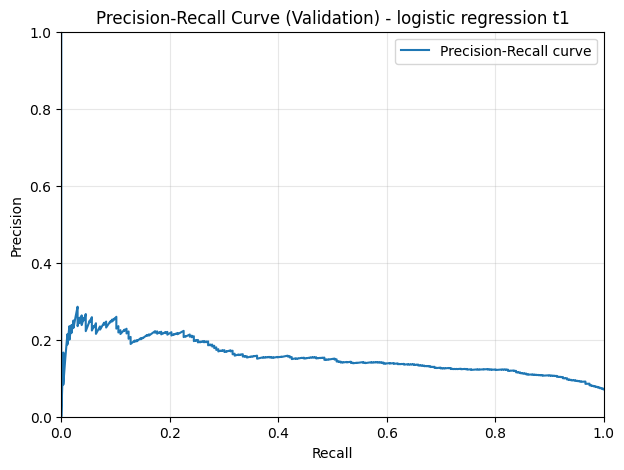

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - logistic regression {HORIZON}",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.25].head(20)

,threshold,precision,recall
3647,0.828526,0.254717,0.101504
3645,0.827114,0.250000,0.101504
3646,0.828289,0.252336,0.101504
3648,0.829741,0.257143,0.101504
3649,0.830400,0.259615,0.101504
3650,0.831223,0.252427,0.097744
3651,0.832753,0.254902,0.097744
3653,0.834177,0.250000,0.093985
3654,0.834367,0.252525,0.093985
3693,0.859718,0.250000,0.056391


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

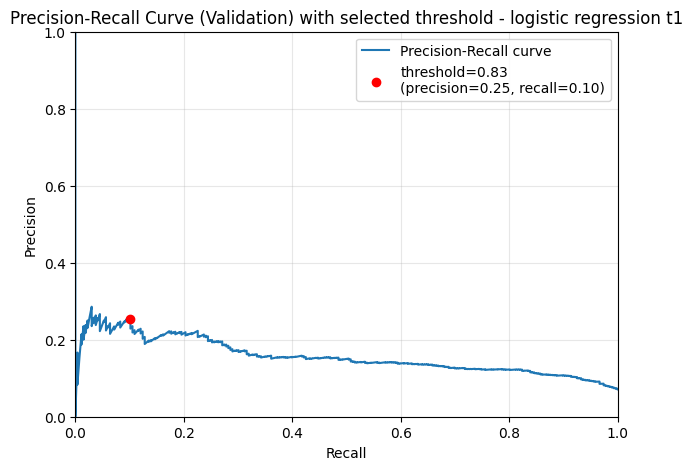

In [6]:
SELECTED_THRESHOLD = 0.828526

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - logistic regression {HORIZON}",
);

## Final evaluation

In [7]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.129608,0.141129,0.026355,0.044416,0.144444,0.009789
val,0.157531,0.257143,0.101504,0.145553,0.244444,0.082707
test,0.134022,0.191176,0.104839,0.135417,0.188889,0.045699


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [8]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t1.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/log_reg_t1.joblib')